# QVHighlights EDA

Ноутбук воспроизводит первичный анализ JSONL-аннотаций QVHighlights: размеры сплитов, длительности видео, интервалы релевантных моментов, saliency-оценки трёх аннотаторов и проверки качества разметки.

In [1]:
from pathlib import Path
import json
import os
import sys

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'scripts').exists() else cwd.parent
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.mplconfig'))
from qvhighlights_eda import SPLIT_FILES, load_jsonl, summarize_split, merge_windows

In [2]:
data_dir = PROJECT_ROOT / 'data' / 'qvhighlights'
rows_by_split = {split: load_jsonl(data_dir / file) for split, file in SPLIT_FILES.items()}
{split: len(rows) for split, rows in rows_by_split.items()}

{'train': 7218, 'val': 1550, 'test': 1542}

In [3]:
summary = {}
examples = {}
issues = []
for split, rows in rows_by_split.items():
    split_summary, split_examples, split_issues = summarize_split(split, rows)
    summary[split] = split_summary
    examples[split] = split_examples
    issues.extend(split_issues)

summary

{'train': {'split': 'train',
  'rows': 7218,
  'unique_qids': 7218,
  'unique_videos': 7100,
  'duration_sec': {'min': 120.0,
   'p25': 150.0,
   'median': 150.0,
   'p75': 150.0,
   'max': 150.0,
   'mean': 149.54835134386258,
   'total_hours': 299.84444444444443},
  'query_words': {'min': 4.0,
   'p25': 8.0,
   'median': 10.0,
   'p75': 13.0,
   'max': 44.0,
   'mean': 10.46231643114436},
  'windows_per_annotated_video': {'min': 1.0,
   'p25': 1.0,
   'median': 1.0,
   'p75': 2.0,
   'max': 24.0,
   'mean': 1.7737600443336103},
  'window_length_sec': {'min': 2.0,
   'p25': 6.0,
   'median': 16.0,
   'p75': 30.0,
   'max': 150.0,
   'mean': 25.083652268999455},
  'relevant_coverage_ratio': {'min': 0.09333333333333334,
   'p25': 0.14666666666666667,
   'median': 0.2,
   'p75': 0.3466666666666667,
   'max': 1.0,
   'mean': 0.29755912510492416},
  'relevant_clip_count': {'min': 7.0,
   'p25': 11.0,
   'median': 15.0,
   'p75': 26.0,
   'max': 75.0,
   'mean': 22.24619008035467},
  'salie

In [4]:
for split, items in examples.items():
    print(f'--- {split} ---')
    for item in items[:2]:
        print(json.dumps(item, ensure_ascii=False))

--- train ---
{"qid": 9769, "vid": "j7rJstUseKg_360.0_510.0", "duration": 150, "query": "some military patriots takes us through their safety procedures and measures.", "relevant_windows": [[72, 82], [84, 94], [96, 106], [108, 118], [120, 130], [136, 142], [144, 146]]}
{"qid": 10016, "vid": "j7rJstUseKg_210.0_360.0", "duration": 150, "query": "Man in baseball cap eats before doing his interview.", "relevant_windows": [[96, 114]]}
--- val ---
{"qid": 2579, "vid": "NUsG9BgSes0_210.0_360.0", "duration": 150, "query": "A girl and her mother cooked while talking with each other on facetime.", "relevant_windows": [[82, 150]]}
{"qid": 5071, "vid": "NUsG9BgSes0_60.0_210.0", "duration": 150, "query": "A woman sitting in front of a desk wearing headphones and using her laptop", "relevant_windows": [[118, 136]]}
--- test ---
{"qid": 3158, "vid": "_6hnl_BrFvs_360.0_510.0", "duration": 150, "query": "A video covering hill and water from a boat", "relevant_windows": []}
{"qid": 7920, "vid": "_6hnl_B

In [5]:
import pandas as pd

table = []
for split, stats in summary.items():
    table.append({
        'split': split,
        'rows': stats['rows'],
        'unique_videos': stats['unique_videos'],
        'total_hours': stats['duration_sec']['total_hours'],
        'median_duration_sec': stats['duration_sec']['median'],
        'mean_coverage_ratio': stats['relevant_coverage_ratio']['mean'],
        'issue_count': stats['issue_count'],
    })
pd.DataFrame(table)

,split,rows,unique_videos,total_hours,median_duration_sec,mean_coverage_ratio,issue_count
0,train,7218,7100,299.844444,150.0,0.297559,0
1,val,1550,1519,64.418333,150.0,0.280774,0
2,test,1542,1529,64.063889,150.0,NaN,0


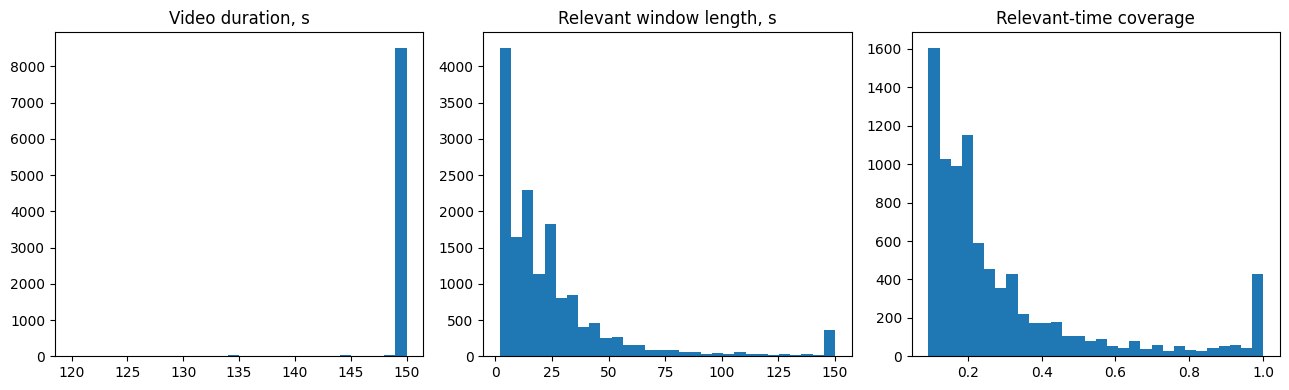

In [6]:
import matplotlib.pyplot as plt

train_val = [r for split in ('train', 'val') for r in rows_by_split[split]]
durations = [r['duration'] for r in train_val]
window_lengths = [float(e) - float(s) for r in train_val for s, e in r['relevant_windows']]
coverage = []
for r in train_val:
    merged = merge_windows(r['relevant_windows'])
    coverage.append(sum(e - s for s, e in merged) / float(r['duration']))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(durations, bins=30)
axes[0].set_title('Video duration, s')
axes[1].hist(window_lengths, bins=30)
axes[1].set_title('Relevant window length, s')
axes[2].hist(coverage, bins=30)
axes[2].set_title('Relevant-time coverage')
fig.tight_layout()

(Counter({4: 232967, 3: 176910, 2: 107442, 1: 42831, 0: 19216}),
 Counter({1: 82293, 2: 60052, 3: 22338, 0: 20993, 4: 7446}))

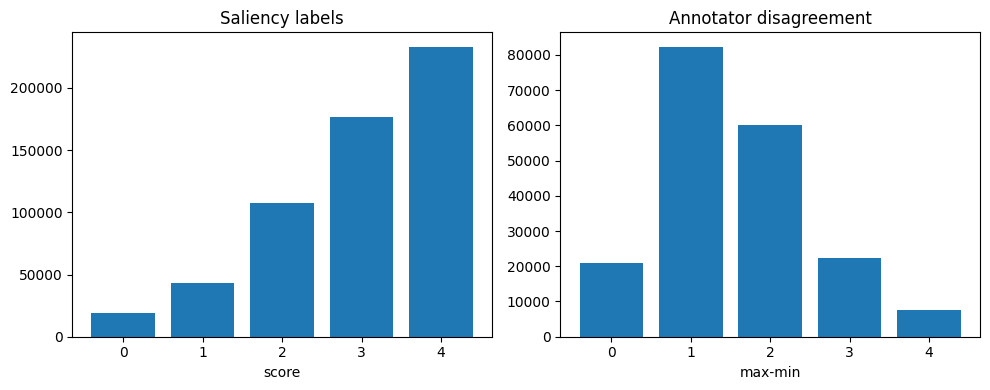

In [7]:
from collections import Counter

score_counter = Counter()
spread_counter = Counter()
for r in train_val:
    for triplet in r['saliency_scores']:
        score_counter.update(triplet)
        spread_counter[max(triplet) - min(triplet)] += 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(range(5), [score_counter[i] for i in range(5)])
axes[0].set_title('Saliency labels')
axes[0].set_xlabel('score')
axes[1].bar(range(5), [spread_counter[i] for i in range(5)])
axes[1].set_title('Annotator disagreement')
axes[1].set_xlabel('max-min')
fig.tight_layout()
score_counter, spread_counter

In [8]:
print(f'Quality issues found: {len(issues)}')
issues[:20]

Quality issues found: 0


[]